# Longitudinal boundary-condition comparison with monochromatic sources

This notebook characterizes Wakis' longitudinal (`z-`, `z+`) PEC, first-order Mur ABC, CPML, and periodic boundary conditions using a sinusoidally modulated `WavePacket`. The finite Gaussian envelope makes boundary returns identifiable, while the carrier is monochromatic. The transverse boundaries are periodic so that the experiment isolates the longitudinal boundary behavior.

The expected qualitative behavior is:

- **PEC:** the pulse reflects with approximately unit magnitude and reversed electric-field sign.
- **ABC (Mur):** a first-order outgoing-wave update is applied to tangential electric fields at both longitudinal faces. It is a low-cost absorber and is expected to reflect more than CPML.
- **CPML:** the outgoing pulse is absorbed with little reflected field.
- **Periodic:** the pulse leaving one longitudinal face re-enters through the opposite face.

In [19]:
import sys

import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import numpy as np
from IPython.display import HTML
from tqdm.auto import tqdm

sys.path.append("../")

from wakis.gridFIT3D import GridFIT3D
from wakis.solverFIT3D import SolverFIT3D
from wakis.sources import PlaneWave, WavePacket

## Simulation configuration

The physical domain is long in `z`. The default `WavePacket` is a finite, sinusoidally modulated packet. Set `source_kind` to `"plane_wave"` to rerun the same boundary matrix with a continuous monochromatic source.

In [20]:
Nx = Ny = 8
Nz = 200

xmin, xmax = -0.025, 0.025
ymin, ymax = -0.025, 0.025
zmin, zmax = 0.0, 0.5

dt = 2.5e-12
Nt = 1600
packet_sigma_z = 0.05
packet_sigma_xy = 0.10
plane_wave_frequency = 6.0e9
source_kind = "wave_packet"  # choose "wave_packet" or "plane_wave"
source_label = {
    "wave_packet": f"{plane_wave_frequency / 1e9} GHz Gaussian-envelope wave packet",
    "plane_wave": f"{plane_wave_frequency / 1e9} GHz plane wave",
}[source_kind]
frame_stride = 20  # store one x-z field frame every 50 ps
source_k = 50
probe_k = 80
n_pml = 10

time = np.arange(Nt) * dt

boundary_cases = {
    "PEC": {"boundary": "pec"},
    "ABC": {"boundary": "abc"},
    "CPML": {
        "boundary": "cpml",
        "n_pml": n_pml,
        "kappa_max": 5,
        "alpha_max": 0.05,
        "pml_exp": 4,
        "sigma_factor": 1.0,
    },
    "Periodic": {"boundary": "periodic"},
}

colors = {
    "Reference": "black",
    "PEC": "tab:blue",
    "ABC": "tab:orange",
    "CPML": "tab:green",
    "Periodic": "tab:red",
}

## Boundary-case runner

Each case uses the same grid, source, timestep, and probe. Besides the probe trace, the complete centerline is retained at every timestep for a `z-t` propagation map.

In [21]:
def make_source(zs):
    if source_kind == "wave_packet":
        return WavePacket(
            xs=slice(0, Nx),
            ys=slice(0, Ny),
            zs=zs,
            sigmaz=packet_sigma_z,
            sigmaxy=packet_sigma_xy,
            f=plane_wave_frequency,
            amplitude=1.0,
        )
    if source_kind == "plane_wave":
        return PlaneWave(
            xs=slice(0, Nx),
            ys=slice(0, Ny),
            zs=zs,
            f=plane_wave_frequency,
            amplitude=1.0,
            phase=-np.pi / 2,
        )
    raise ValueError(f"Unsupported source_kind: {source_kind}")


def run_source_case(name, case):
    grid = GridFIT3D(xmin, xmax, ymin, ymax, zmin, zmax, Nx, Ny, Nz, verbose=0)
    longitudinal_bc = case["boundary"]
    bc_low = ["periodic", "periodic", longitudinal_bc]
    bc_high = ["periodic", "periodic", longitudinal_bc]
    solver_kwargs = {key: value for key, value in case.items() if key != "boundary"}

    solver = SolverFIT3D(
        grid,
        bc_low=bc_low,
        bc_high=bc_high,
        dt=dt,
        verbose=0,
        **solver_kwargs,
    )
    source = make_source(source_k)

    probe = np.zeros(Nt)
    history = np.zeros((Nt, Nz))
    frame_indices = np.arange(0, Nt, frame_stride)
    history_2d = np.empty((len(frame_indices), Nx, Nz), dtype=np.float32)
    for n in tqdm(range(Nt), desc=name, leave=False):
        source.update(solver, n * solver.dt)
        solver.one_step()
        probe[n] = solver.E[Nx // 2, Ny // 2, probe_k, "x"]
        history[n] = solver.E[Nx // 2, Ny // 2, :, "x"]
        if n % frame_stride == 0:
            history_2d[n // frame_stride] = solver.E[:, Ny // 2, :, "x"]

    return {
        "probe": probe,
        "history": history,
        "history_2d": history_2d,
        "frame_time": time[frame_indices],
        "z": solver.z.copy(),
        "dt": float(solver.dt),
    }


results = {name: run_source_case(name, case) for name, case in boundary_cases.items()}

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


PEC:   0%|          | 0/1600 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


ABC:   0%|          | 0/1600 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...
[!] CPML requires Total-Field/Scattered-Field injection, setting source_type='tfsf'


CPML:   0%|          | 0/1600 [00:00<?, ?it/s]

Generating grid with 12800 mesh cells...
Initializing Electromagnetic solver...


Periodic:   0%|          | 0/1600 [00:00<?, ?it/s]

## Extended-domain incident reference

The reference grid has the same cell sizes but is extended far beyond both ends of the comparison domain. Its PEC reflections cannot return to the probe during the simulated time, so its probe trace represents the incident field. This avoids constructing a zero-cell CPML reference.

In [22]:
reference_zmin, reference_zmax = -0.5, 1.0
reference_Nz = 600
reference_source_k = source_k + 200
reference_probe_k = probe_k + 200

reference_grid = GridFIT3D(
    xmin,
    xmax,
    ymin,
    ymax,
    reference_zmin,
    reference_zmax,
    Nx,
    Ny,
    reference_Nz,
    verbose=0,
)
reference_solver = SolverFIT3D(
    reference_grid,
    bc_low=["periodic", "periodic", "pec"],
    bc_high=["periodic", "periodic", "pec"],
    dt=dt,
    verbose=0,
)
reference_source = make_source(reference_source_k)

reference_probe = np.zeros(Nt)
for n in tqdm(range(Nt), desc="Reference", leave=False):
    reference_source.update(reference_solver, n * reference_solver.dt)
    reference_solver.one_step()
    reference_probe[n] = reference_solver.E[Nx // 2, Ny // 2, reference_probe_k, "x"]

Generating grid with 38400 mesh cells...
Initializing Electromagnetic solver...


Reference:   0%|          | 0/1600 [00:00<?, ?it/s]

## Time-domain probe comparison

The first pulse at the probe is the common `z+` incident field. Later activity identifies the high-face response: a sign-reversed PEC return, small residuals for the absorbers, and a delayed periodic re-entry.

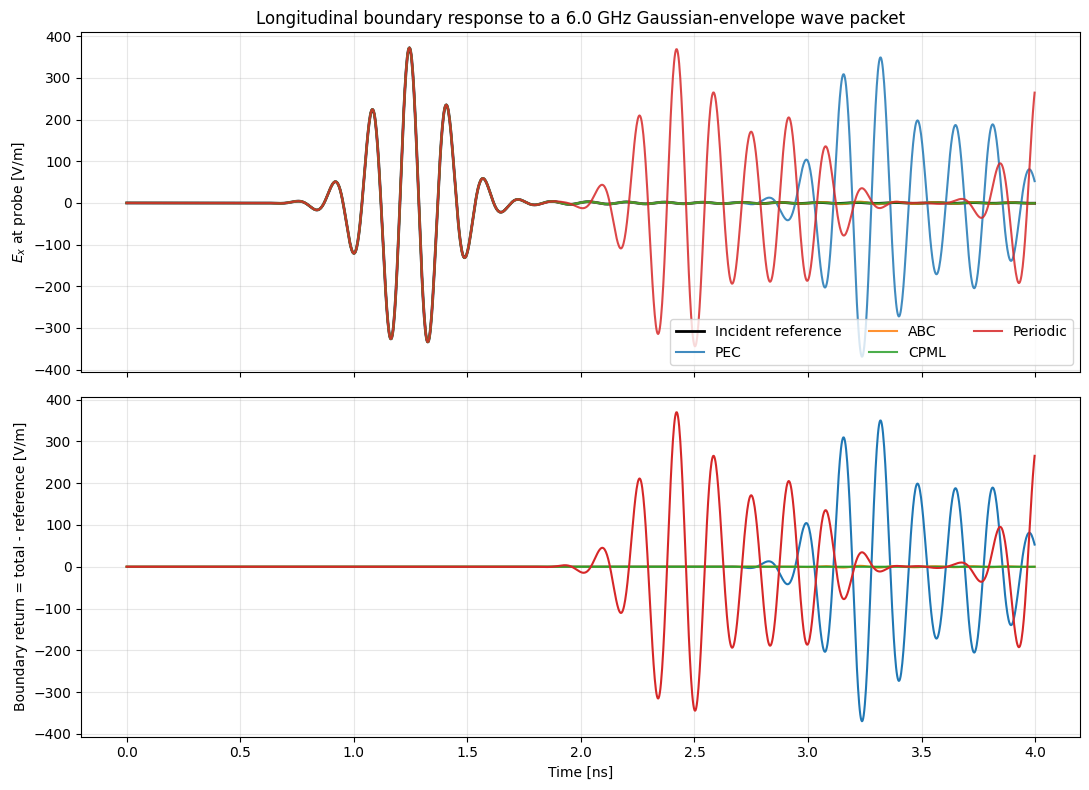

In [23]:
fig, axes = plt.subplots(2, 1, figsize=(11, 8), sharex=True)
axes[0].plot(
    time * 1e9,
    reference_probe,
    color=colors["Reference"],
    label="Incident reference",
    linewidth=2,
)
for name, result in results.items():
    axes[0].plot(
        time * 1e9, result["probe"], color=colors[name], label=name, alpha=0.85
    )
    axes[1].plot(
        time * 1e9,
        result["probe"] - reference_probe,
        color=colors[name],
        label=name,
    )

axes[0].set_ylabel(r"$E_x$ at probe [V/m]")
axes[0].set_title(f"Longitudinal boundary response to a {source_label}")
axes[0].legend(ncol=3)
axes[1].set_xlabel("Time [ns]")
axes[1].set_ylabel("Boundary return = total - reference [V/m]")
for ax in axes:
    ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Longitudinal propagation maps

These maps make the boundary mechanism visible across the whole domain. The source plane is marked in black. Dashed gray lines mark the inner edges of the CPML layers.

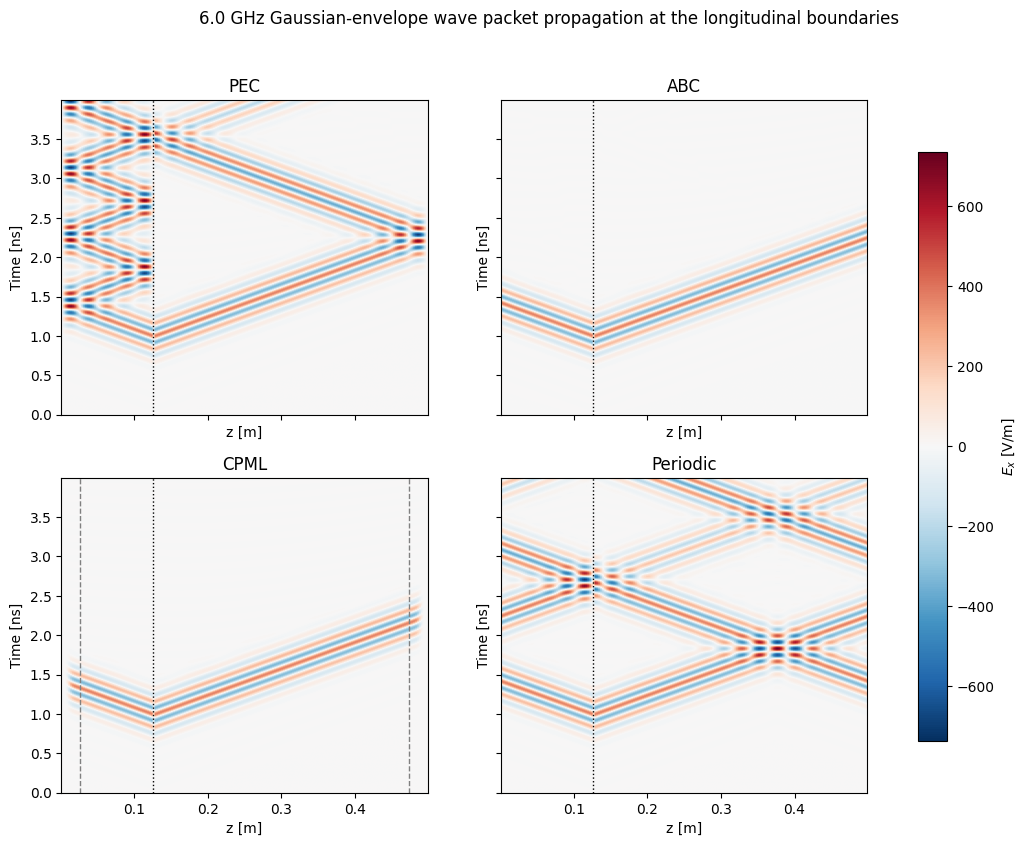

In [24]:
field_limit = max(np.abs(result["history"]).max() for result in results.values())
fig, axes = plt.subplots(2, 2, figsize=(13, 9), sharex=True, sharey=True)
for ax, (name, result) in zip(axes.flat, results.items()):
    image = ax.imshow(
        result["history"],
        origin="lower",
        aspect="auto",
        extent=[result["z"][0], result["z"][-1], time[0] * 1e9, time[-1] * 1e9],
        cmap="RdBu_r",
        vmin=-field_limit,
        vmax=field_limit,
    )
    ax.axvline(result["z"][source_k], color="black", linestyle=":", linewidth=1)
    if name == "CPML":
        ax.axvline(result["z"][n_pml], color="gray", linestyle="--", linewidth=1)
        ax.axvline(result["z"][-n_pml - 1], color="gray", linestyle="--", linewidth=1)
    ax.set_title(name)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("Time [ns]")

fig.colorbar(image, ax=axes, label=r"$E_x$ [V/m]", shrink=0.85)
fig.suptitle(f"{source_label} propagation at the longitudinal boundaries", y=0.98)
plt.show()

## Animated two-dimensional field view

This `x-z` animation is taken through the central `y` plane. All four panels share a fixed color scale, so changes in the packet amplitude can be distinguished from automatic color rescaling. Frames are sampled every 50 ps to keep the notebook compact.

In [25]:
field_limit_2d = max(np.abs(result["history_2d"]).max() for result in results.values())
fig, axes = plt.subplots(2, 2, figsize=(12, 7), sharex=True, sharey=True)
images = []
for ax, (name, result) in zip(axes.flat, results.items()):
    image = ax.imshow(
        result["history_2d"][0],
        origin="lower",
        aspect="auto",
        extent=[result["z"][0], result["z"][-1], xmin, xmax],
        cmap="RdBu_r",
        vmin=-field_limit_2d,
        vmax=field_limit_2d,
    )
    images.append(image)
    ax.axvline(result["z"][source_k], color="black", linestyle=":", linewidth=1)
    if name == "CPML":
        ax.axvline(result["z"][n_pml], color="gray", linestyle="--", linewidth=1)
        ax.axvline(result["z"][-n_pml - 1], color="gray", linestyle="--", linewidth=1)
    ax.set_xlabel("z [m]")
    ax.set_ylabel("x [m]")

colorbar = fig.colorbar(images[-1], ax=axes, label=r"$E_x$ [V/m]", shrink=0.88)
title = fig.suptitle("")


def update_frame(frame):
    frame_time = next(iter(results.values()))["frame_time"][frame] * 1e9
    for image, (name, result) in zip(images, results.items()):
        image.set_data(result["history_2d"][frame])
        image.axes.set_title(name)
    title.set_text(
        f"{source_label}: $E_x$ in the central x-z plane at {frame_time:.3f} ns"
    )
    return [*images, title]


animation = FuncAnimation(
    fig,
    update_frame,
    frames=len(next(iter(results.values()))["frame_time"]),
    interval=100,
)
plt.close(fig)
HTML(animation.to_jshtml())

## Spectral boundary-return estimate

The residual spectrum is the Fourier transform of `total - incident reference`, normalized by the incident power spectrum where the incident signal is sufficiently resolved. For Mur ABC and CPML this estimates boundary return. For PEC and periodic boundaries it measures the expected returned pulse rather than absorption quality.

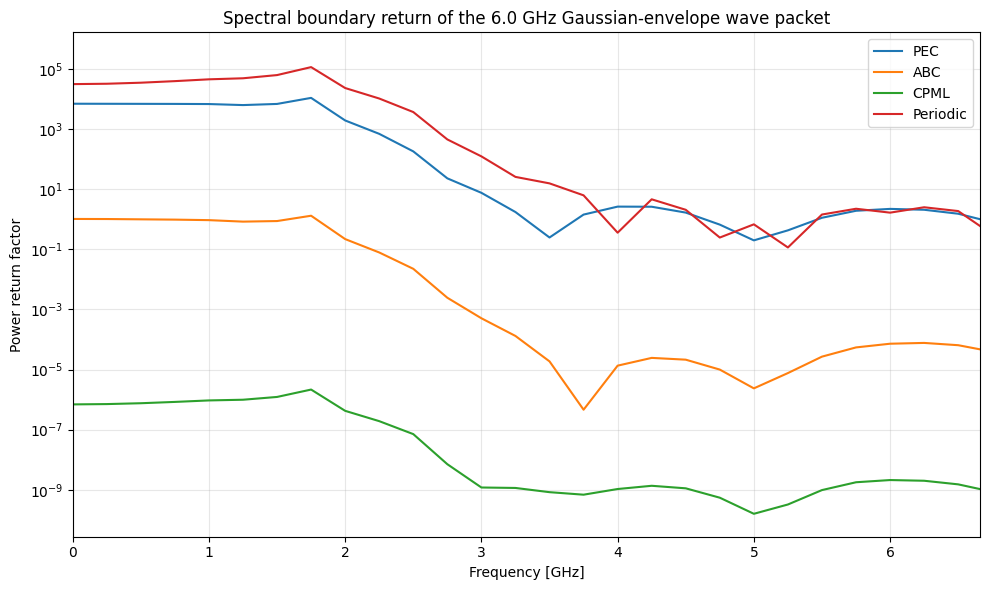

In [26]:
frequency = np.fft.rfftfreq(Nt, dt)
incident_spectrum = np.fft.rfft(reference_probe)
resolved = np.abs(incident_spectrum) > 1e-6 * np.abs(incident_spectrum).max()

fig, ax = plt.subplots(figsize=(10, 6))
for name, result in results.items():
    residual_spectrum = np.fft.rfft(result["probe"] - reference_probe)
    return_factor = np.full_like(frequency, np.nan, dtype=float)
    return_factor[resolved] = (
        np.abs(residual_spectrum[resolved]) / np.abs(incident_spectrum[resolved])
    ) ** 2
    ax.plot(frequency * 1e-9, return_factor, color=colors[name], label=name)

ax.set(
    xlabel="Frequency [GHz]",
    ylabel="Power return factor",
    title=f"Spectral boundary return of the {source_label}",
    xlim=(0, 6.66),
)
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()

## Diagnostic return amplitudes

These peak residuals are aids for comparing runs, not acceptance tolerances. The early window contains the common incident wave; the later window contains high-face reflection or periodic wrap-around.

In [27]:
diagnostic_windows = {
    "incident-wave agreement": (0.55e-9, 1.25e-9),
    "high-face / periodic return": (2.00e-9, 3.80e-9),
}

print(f"Incident peak at probe: {np.abs(reference_probe).max():.6e} V/m")
for label, (start, stop) in diagnostic_windows.items():
    window = (time >= start) & (time < stop)
    print(f"\n{label} ({start * 1e9:.2f}-{stop * 1e9:.2f} ns)")
    for name, result in results.items():
        residual = result["probe"] - reference_probe
        window_indices = np.flatnonzero(window)
        peak_n = window_indices[np.abs(residual[window]).argmax()]
        print(
            f"  {name:8s}: {residual[peak_n]:+.6e} V/m at {time[peak_n] * 1e9:.3f} ns"
        )

if source_kind == "wave_packet":
    print("\nForward-packet peak at interior centerline locations (PEC case):")
    packet_center_time = 6 * packet_sigma_z / 299_792_458.0
    for k in (source_k + 20, source_k + 50, source_k + 80):
        center_time = (
            packet_center_time
            + (results["PEC"]["z"][k] - results["PEC"]["z"][source_k]) / 299_792_458.0
        )
        window = np.abs(time - center_time) < 0.15e-9
        peak = np.abs(results["PEC"]["history"][window, k]).max()
        print(f"  z={results['PEC']['z'][k]:.3f} m: {peak:.6e} V/m")

Incident peak at probe: 3.723648e+02 V/m

incident-wave agreement (0.55-1.25 ns)
  PEC     : +1.818989e-12 V/m at 1.225 ns
  ABC     : +1.705303e-12 V/m at 1.225 ns
  CPML    : +2.046363e-12 V/m at 1.225 ns
  Periodic: +1.705303e-12 V/m at 1.225 ns

high-face / periodic return (2.00-3.80 ns)
  PEC     : -3.698016e+02 V/m at 3.237 ns
  ABC     : +2.163923e+00 V/m at 3.230 ns
  CPML    : -1.199556e-02 V/m at 3.260 ns
  Periodic: +3.695517e+02 V/m at 2.420 ns

Forward-packet peak at interior centerline locations (PEC case):
  z=0.176 m: 3.678405e+02 V/m
  z=0.251 m: 3.695619e+02 V/m
  z=0.326 m: 3.703427e+02 V/m
